In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt


In [2]:
audio_dir = "/Users/lafiloche31200/Projects/projet_donnee/audio"
json_path = "/Users/lafiloche31200/Projects/projet_donnee/train_val_annotation/train_val_videodatainfo.json"

# Charger JSON MSR-VTT
with open(json_path, "r") as f:
    data = json.load(f)

videos = data["videos"]

# Créer DataFrame des vidéos
df_videos = pd.DataFrame(videos)

# Dictionnaire des catégories
categories = {
    0: "music",
    1: "people",
    2: "gaming",
    3: "sports/actions",
    4: "news/events/politics",
    5: "education",
    6: "tv shows",
    7: "movie/comedy",
    8: "animation",
    9: "vehicles/autos",
    10: "howto",
    11: "travel",
    12: "science/technology",
    13: "animals/pets",
    14: "kids/family",
    15: "documentary",
    16: "food/drink",
    17: "cooking",
    18: "beauty/fashion",
    19: "advertisement"
}

# Ajouter nom de catégorie
df_videos['category_name'] = df_videos['category'].map(categories)



In [3]:
durations = []
category_list = []

for file in os.listdir(audio_dir):
    if file.endswith(".wav"):
        file_path = os.path.join(audio_dir, file)
        y, sr = librosa.load(file_path, sr=None)
        durations.append(len(y)/sr)
        
        # Associer la catégorie depuis le JSON
        video_id = os.path.splitext(file)[0]
        cat = df_videos[df_videos["video_id"] == video_id]["category_name"].values
        category_list.append(cat[0] if len(cat) > 0 else "Unknown")

durations = np.array(durations)


In [4]:
print("=== Statistiques générales audio ===")
print(f"Nombre de fichiers audio : {len(durations)}")
print(f"Durée moyenne (sec) : {durations.mean():.2f}")
print(f"Durée médiane (sec) : {np.median(durations):.2f}")
print(f"Durée minimale (sec) : {durations.min():.2f}")
print(f"Durée maximale (sec) : {durations.max():.2f}")
print(f"Écart-type (sec) : {durations.std():.2f}")


=== Statistiques générales audio ===
Nombre de fichiers audio : 6176
Durée moyenne (sec) : 14.89
Durée médiane (sec) : 13.01
Durée minimale (sec) : 9.60
Durée maximale (sec) : 30.01
Écart-type (sec) : 5.06


In [5]:
df_audio = pd.DataFrame({
    "duration": durations,
    "category": category_list
})

# Nombre de fichiers par catégorie
count_by_category = df_audio["category"].value_counts()
print("\nNombre de fichiers audio par catégorie :")
print(count_by_category)

# Durée moyenne par catégorie
mean_duration_by_category = df_audio.groupby("category")["duration"].mean()
print("\nDurée moyenne des fichiers audio par catégorie :")
print(mean_duration_by_category)



Nombre de fichiers audio par catégorie :
category
sports/actions          733
movie/comedy            594
vehicles/autos          520
food/drink              430
music                   406
animals/pets            388
kids/family             345
howto                   327
beauty/fashion          324
news/events/politics    314
gaming                  285
science/technology      232
cooking                 218
animation               189
travel                  175
tv shows                175
education               171
people                  155
documentary             104
advertisement            91
Name: count, dtype: int64

Durée moyenne des fichiers audio par catégorie :
category
advertisement           13.296904
animals/pets            15.332818
animation               13.939114
beauty/fashion          15.144984
cooking                 14.653481
documentary             15.845039
education               15.415567
food/drink              15.612535
gaming                  14.02418

In [6]:
# Durée moyenne par catégorie
mean_duration_by_category = df_audio.groupby("category")["duration"].mean()
print("\nDurée moyenne des fichiers audio par catégorie :")
print(mean_duration_by_category)



Durée moyenne des fichiers audio par catégorie :
category
advertisement           13.296904
animals/pets            15.332818
animation               13.939114
beauty/fashion          15.144984
cooking                 14.653481
documentary             15.845039
education               15.415567
food/drink              15.612535
gaming                  14.024182
howto                   15.129607
kids/family             13.485669
movie/comedy            14.343803
music                   14.153900
news/events/politics    15.499198
people                  15.127030
science/technology      15.767888
sports/actions          15.005651
travel                  15.685050
tv shows                14.830958
vehicles/autos          15.357914
Name: duration, dtype: float64


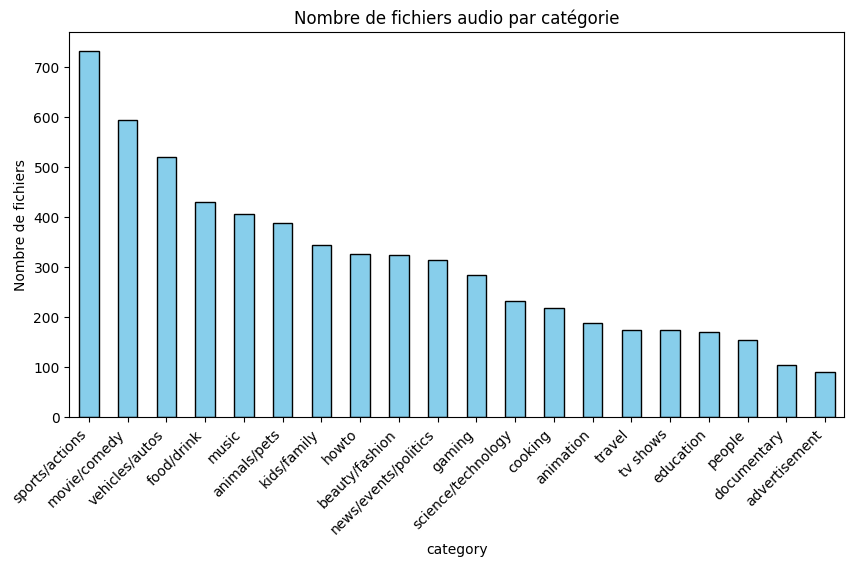

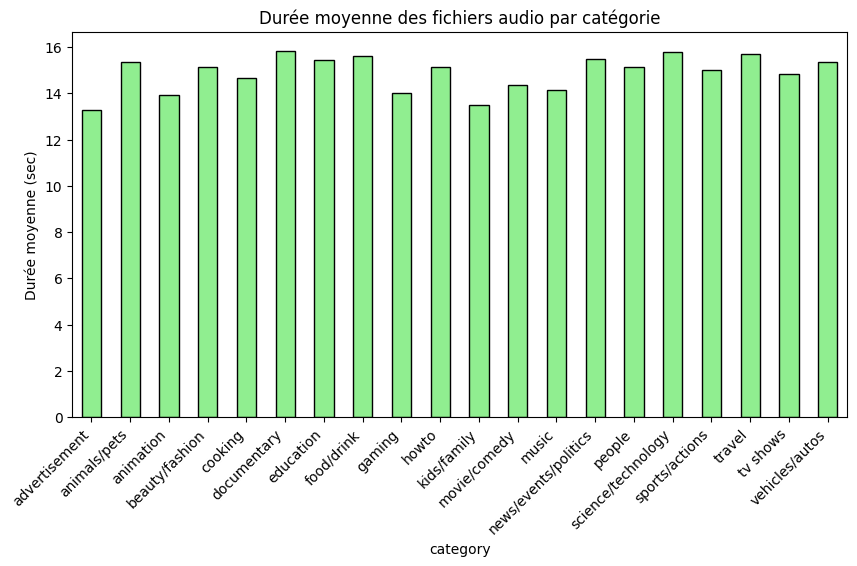

In [7]:
plt.figure(figsize=(10,5))
count_by_category.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Nombre de fichiers audio par catégorie")
plt.ylabel("Nombre de fichiers")
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(10,5))
mean_duration_by_category.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Durée moyenne des fichiers audio par catégorie")
plt.ylabel("Durée moyenne (sec)")
plt.xticks(rotation=45, ha='right')
plt.show()


# description audio : conette
# pyanote speackeyr 
# whisper 